In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# set paths

project_dir = r"C:\Users\Kimi\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement"

processed_dir = os.path.join(project_dir, "data_processed")
outputs_dir = os.path.join(project_dir, "outputs")
tables_dir = os.path.join(outputs_dir, "tables")
charts_dir = os.path.join(outputs_dir, "charts")

os.makedirs(processed_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print("Processed dir:", processed_dir)

Processed dir: C:\Users\Kimi\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\data_processed


In [3]:
# load merged dataset

df = pd.read_csv(
    os.path.join(processed_dir, "member_features_with_engagement_2010.csv"),
    low_memory=False
)

print("Shape:", df.shape)
df.head()

Shape: (112754, 72)


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,portal_logins_90d,app_sessions_90d,care_reminder_clicks_90d,care_team_messages_90d,scheduled_telehealth_90d,preventive_content_views_90d,engagement_score,engagement_tier,low_engagement_member,outreach_priority_flag
0,00013D2EFD8E45D1,1970-01-01 00:00:00.019230501,NaN,1,1,0,26,950,12,12,...,5,9,4,2,0,4,26.75,Very High,0,0
1,00016F745862898F,1970-01-01 00:00:00.019430101,NaN,1,1,Y,39,230,12,12,...,4,4,5,5,0,5,30.75,Very High,0,0
2,0001FDD721E223DC,1970-01-01 00:00:00.019360901,NaN,2,1,0,39,280,12,12,...,3,4,1,0,0,1,8.75,Low,1,0
3,00021CA6FF03E670,1970-01-01 00:00:00.019410601,NaN,1,5,0,6,290,12,12,...,1,1,0,1,0,2,6.25,Low,1,0
4,00024B3D2352D2D0,1970-01-01 00:00:00.019360801,NaN,1,1,0,52,590,9,12,...,4,10,0,1,0,1,14.75,Medium,0,0


In [4]:
# quick sanity check of target

print(df["high_cost_member"].value_counts(dropna=False))
print(df["high_cost_member"].value_counts(normalize=True, dropna=False).round(4))

high_cost_member
0    84552
1    28202
Name: count, dtype: int64
high_cost_member
0    0.7499
1    0.2501
Name: proportion, dtype: float64


In [5]:
# review columns

for col in df.columns:
    print(col)

DESYNPUF_ID
BENE_BIRTH_DT
BENE_DEATH_DT
BENE_SEX_IDENT_CD
BENE_RACE_CD
BENE_ESRD_IND
SP_STATE_CODE
BENE_COUNTY_CD
BENE_HI_CVRAGE_TOT_MONS
BENE_SMI_CVRAGE_TOT_MONS
BENE_HMO_CVRAGE_TOT_MONS
PLAN_CVRG_MOS_NUM
SP_ALZHDMTA
SP_CHF
SP_CHRNKIDN
SP_CNCR
SP_COPD
SP_DEPRESSN
SP_DIABETES
SP_ISCHMCHT
SP_OSTEOPRS
SP_RA_OA
SP_STRKETIA
MEDREIMB_IP
BENRES_IP
PPPYMT_IP
MEDREIMB_OP
BENRES_OP
PPPYMT_OP
MEDREIMB_CAR
BENRES_CAR
PPPYMT_CAR
inpatient_claim_count
inpatient_total_paid
inpatient_avg_paid
inpatient_max_paid
inpatient_total_primary_payer_paid
inpatient_total_deductible
inpatient_total_coinsurance
inpatient_total_blood_deductible
inpatient_total_util_days
inpatient_avg_diag_count
has_inpatient_claim
outpatient_claim_count
outpatient_total_paid
outpatient_avg_paid
outpatient_max_paid
outpatient_total_primary_payer_paid
outpatient_total_deductible
outpatient_total_coinsurance
outpatient_total_blood_deductible
outpatient_avg_diag_count
has_outpatient_claim
age_2010
chronic_condition_count
total_paid_a

In [6]:
# choose features for modeling (will not use everything)

feature_cols = [
    "age_2010",
    "BENE_SEX_IDENT_CD",
    "BENE_RACE_CD",
    "BENE_ESRD_IND",
    "BENE_HI_CVRAGE_TOT_MONS",
    "BENE_SMI_CVRAGE_TOT_MONS",
    "BENE_HMO_CVRAGE_TOT_MONS",
    "PLAN_CVRG_MOS_NUM",
    "chronic_condition_count",
    "inpatient_claim_count",
    "outpatient_claim_count",
    "inpatient_total_util_days",
    "inpatient_avg_diag_count",
    "outpatient_avg_diag_count",
    "has_inpatient_claim",
    "has_outpatient_claim",
    "portal_logins_90d",
    "app_sessions_90d",
    "care_reminder_clicks_90d",
    "care_team_messages_90d",
    "scheduled_telehealth_90d",
    "preventive_content_views_90d",
    "engagement_score",
    "low_engagement_member"
]

target_col = "high_cost_member"

In [7]:
# create modeling dataframe

model_df = df[feature_cols + [target_col]].copy()

print("Model df shape:", model_df.shape)
model_df.head()

Model df shape: (112754, 25)


,age_2010,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,chronic_condition_count,inpatient_claim_count,...,has_outpatient_claim,portal_logins_90d,app_sessions_90d,care_reminder_clicks_90d,care_team_messages_90d,scheduled_telehealth_90d,preventive_content_views_90d,engagement_score,low_engagement_member,high_cost_member
0,40.99384,1,1,0,12,12,12,12,2,1.0,...,1.0,5,9,4,2,0,4,26.75,0,0
1,40.99384,1,1,Y,12,12,0,10,4,4.0,...,1.0,4,4,5,5,0,5,30.75,0,1
2,40.99384,2,1,0,12,12,0,12,0,0.0,...,1.0,3,4,1,0,0,1,8.75,1,0
3,40.99384,1,5,0,12,12,0,12,0,0.0,...,0.0,1,1,0,1,0,2,6.25,1,0
4,40.99384,1,1,0,9,12,12,12,0,0.0,...,1.0,4,10,0,1,0,1,14.75,0,0


In [8]:
# check missingness in model variables

model_missing = (
    model_df.isnull()
    .sum()
    .reset_index()
)

model_missing.columns = ["column_name", "missing_count"]
model_missing["missing_pct"] = (
    model_missing["missing_count"] / len(model_df) * 100
).round(2)

model_missing.sort_values("missing_count", ascending=False)

,column_name,missing_count,missing_pct
0,age_2010,0,0.0
13,outpatient_avg_diag_count,0,0.0
23,low_engagement_member,0,0.0
22,engagement_score,0,0.0
21,preventive_content_views_90d,0,0.0
20,scheduled_telehealth_90d,0,0.0
19,care_team_messages_90d,0,0.0
18,care_reminder_clicks_90d,0,0.0
17,app_sessions_90d,0,0.0
16,portal_logins_90d,0,0.0


In [9]:
# separate X and y

X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (112754, 24)
y shape: (112754,)


In [10]:
# define numeric and categorical features

categorical_features = [
    "BENE_SEX_IDENT_CD",
    "BENE_RACE_CD",
    "BENE_ESRD_IND",
    "low_engagement_member",
    "has_inpatient_claim",
    "has_outpatient_claim",
    "scheduled_telehealth_90d"
]

numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['age_2010', 'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS', 'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM', 'chronic_condition_count', 'inpatient_claim_count', 'outpatient_claim_count', 'inpatient_total_util_days', 'inpatient_avg_diag_count', 'outpatient_avg_diag_count', 'portal_logins_90d', 'app_sessions_90d', 'care_reminder_clicks_90d', 'care_team_messages_90d', 'preventive_content_views_90d', 'engagement_score']

Categorical features: ['BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND', 'low_engagement_member', 'has_inpatient_claim', 'has_outpatient_claim', 'scheduled_telehealth_90d']


In [11]:
# train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("y_test distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train: (90203, 24)
X_test: (22551, 24)
y_train distribution:
high_cost_member
0    0.7499
1    0.2501
Name: proportion, dtype: float64
y_test distribution:
high_cost_member
0    0.7499
1    0.2501
Name: proportion, dtype: float64


In [12]:
# build preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
# build logistic regression model

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [14]:
# fit logistic regression model

logreg_pipeline.fit(X_train, y_train)
print("Logistic regression model fitted.")

Logistic regression model fitted.


In [15]:
# score logistic regression

y_pred_logreg = logreg_pipeline.predict(X_test)
y_prob_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

logreg_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_logreg),
    "precision": precision_score(y_test, y_pred_logreg),
    "recall": recall_score(y_test, y_pred_logreg),
    "f1": f1_score(y_test, y_pred_logreg),
    "roc_auc": roc_auc_score(y_test, y_prob_logreg)
}

logreg_metrics

{'model': 'Logistic Regression',
 'accuracy': 0.9213782093920447,
 'precision': 0.8421518315342418,
 'recall': 0.8437943262411347,
 'f1': 0.8429722788061288,
 'roc_auc': 0.9772122492766679}

In [16]:
# logistic regression confusion matrix and report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Confusion Matrix:
[[16019   892]
 [  881  4759]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     16911
           1       0.84      0.84      0.84      5640

    accuracy                           0.92     22551
   macro avg       0.90      0.90      0.90     22551
weighted avg       0.92      0.92      0.92     22551



In [17]:
# build random forest pipeline

rf_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

rf_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", rf_numeric_transformer, numeric_features),
        ("cat", rf_categorical_transformer, categorical_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [18]:
# fit random forest model

rf_pipeline.fit(X_train, y_train)
print("Random forest model fitted.")

Random forest model fitted.


In [19]:
# score random forest

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

rf_metrics

{'model': 'Random Forest',
 'accuracy': 0.9172098798279456,
 'precision': 0.7911714770797963,
 'recall': 0.9088652482269504,
 'f1': 0.8459443848502353,
 'roc_auc': 0.9774236291708238}

In [20]:
# random forest confusion matrix and reporting

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[15558  1353]
 [  514  5126]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     16911
           1       0.79      0.91      0.85      5640

    accuracy                           0.92     22551
   macro avg       0.88      0.91      0.89     22551
weighted avg       0.92      0.92      0.92     22551



In [21]:
# compare model metrics

metrics_df = pd.DataFrame([logreg_metrics, rf_metrics]).round(4)
metrics_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9214,0.8422,0.8438,0.8430,0.9772
1,Random Forest,0.9172,0.7912,0.9089,0.8459,0.9774


In [22]:
# save model comparisons metrics

metrics_df.to_csv(
    os.path.join(tables_dir, "model_comparison_metrics_high_cost.csv"),
    index=False
)

print("Saved model comparison metrics.")

Saved model comparison metrics.


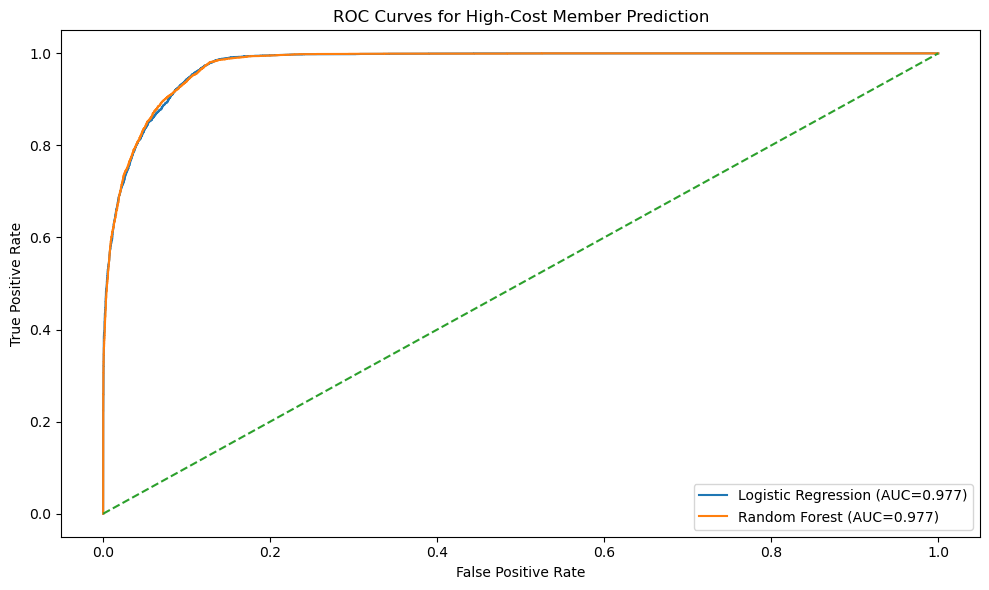

In [23]:
# plot ROC curves

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC={logreg_metrics['roc_auc']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for High-Cost Member Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# extract logistic regression feature names

feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_pipeline.named_steps["model"].coef_[0]

logreg_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

logreg_coef_df["abs_coefficient"] = logreg_coef_df["coefficient"].abs()

logreg_coef_df = logreg_coef_df.sort_values(
    by="abs_coefficient", ascending=False
)

logreg_coef_df.head(20)

,feature,coefficient,abs_coefficient
6,num__inpatient_claim_count,2.178086,2.178086
7,num__outpatient_claim_count,0.952367,0.952367
8,num__inpatient_total_util_days,0.799846,0.799846
28,cat__has_inpatient_claim_1.0,0.778169,0.778169
27,cat__has_inpatient_claim_0.0,-0.775879,0.775879
14,num__care_team_messages_90d,0.472335,0.472335
9,num__inpatient_avg_diag_count,0.308849,0.308849
24,cat__BENE_ESRD_IND_Y,0.161506,0.161506
23,cat__BENE_ESRD_IND_0,-0.159216,0.159216
2,num__BENE_SMI_CVRAGE_TOT_MONS,0.124217,0.124217


In [25]:
# save logistic regression coefficients

logreg_coef_df.to_csv(
    os.path.join(tables_dir, "logistic_regression_coefficients_high_cost.csv"),
    index=False
)

print("Saved logistic regression coefficients.")

Saved logistic regression coefficients.


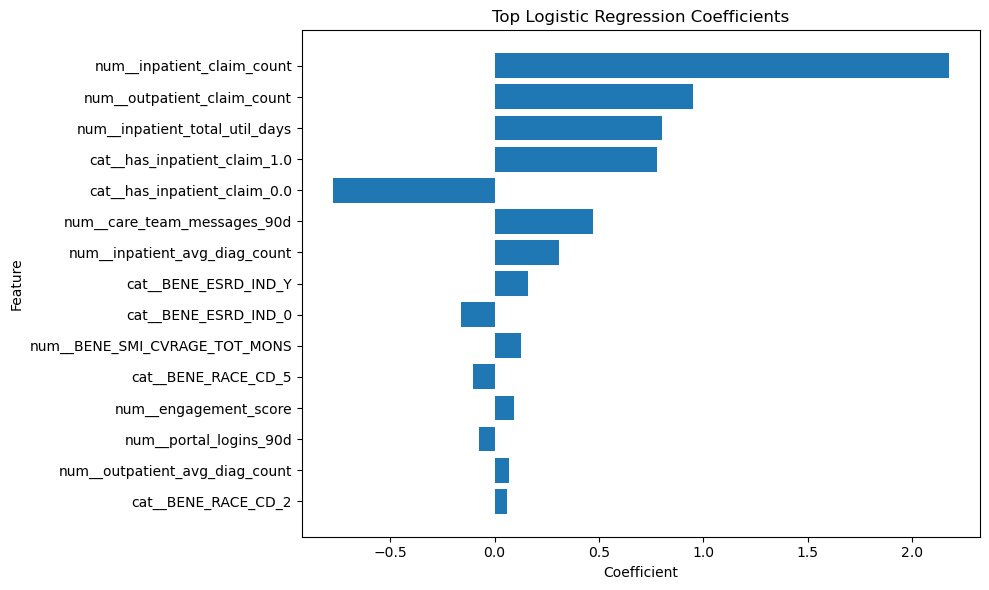

In [26]:
# plot top logistic regression coefficients

top_logreg = logreg_coef_df.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_logreg["feature"], top_logreg["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# extract random forest feature importances

rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances
})

rf_importance_df = rf_importance_df.sort_values(
    by="importance", ascending=False
)

rf_importance_df.head(20)

,feature,importance
6,num__inpatient_claim_count,0.222133
9,num__inpatient_avg_diag_count,0.204046
8,num__inpatient_total_util_days,0.145564
27,cat__has_inpatient_claim_0.0,0.144654
28,cat__has_inpatient_claim_1.0,0.138347
14,num__care_team_messages_90d,0.032031
7,num__outpatient_claim_count,0.030177
16,num__engagement_score,0.019984
5,num__chronic_condition_count,0.019276
10,num__outpatient_avg_diag_count,0.009203


In [28]:
# save random forest importances

rf_importance_df.to_csv(
    os.path.join(tables_dir, "random_forest_feature_importance_high_cost.csv"),
    index=False
)

print("Saved random forest feature importances.")

Saved random forest feature importances.


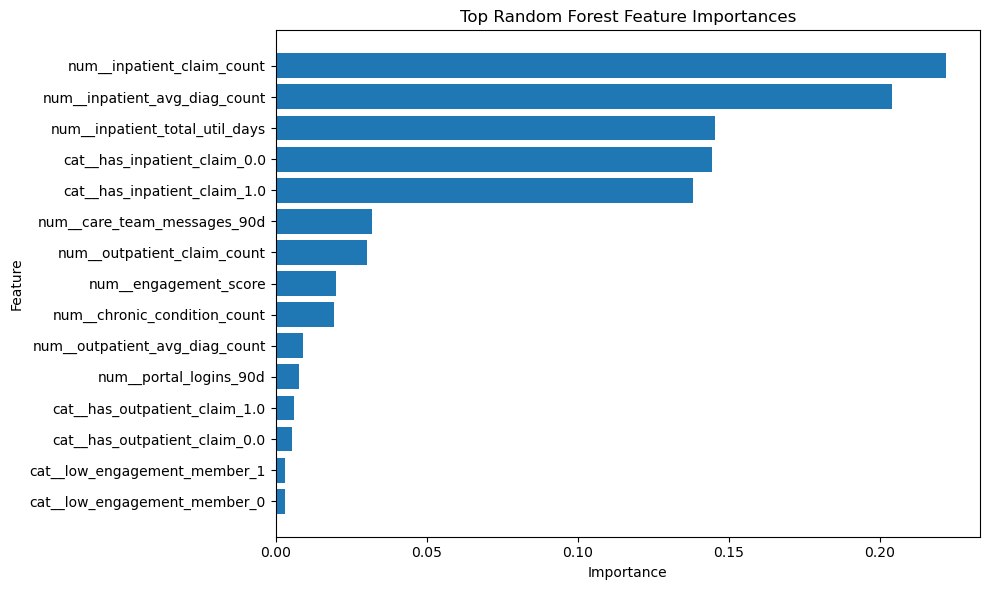

In [29]:
# plot top random forest importances

top_rf = rf_importance_df.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
# score full dataset with better model

best_model = rf_pipeline
best_model_name = "Random Forest"

df["pred_high_cost_probability"] = best_model.predict_proba(X)[:, 1]
df["pred_high_cost_label"] = best_model.predict(X)

print("Using best model:", best_model_name)
df[["pred_high_cost_probability", "pred_high_cost_label"]].head()

Using best model: Random Forest


,pred_high_cost_probability,pred_high_cost_label
0,0.510299,1
1,0.963312,1
2,0.002596,0
3,0.000140,0
4,0.003526,0


In [31]:
# create risk bands from predicted probability

df["predicted_risk_band"] = pd.qcut(
    df["pred_high_cost_probability"],
    q=4,
    labels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"],
    duplicates="drop"
)

print(df["predicted_risk_band"].value_counts(dropna=False))

predicted_risk_band
Low Risk          28189
Very High Risk    28189
Moderate Risk     28188
High Risk         28188
Name: count, dtype: int64


In [32]:
# summary by predicted probability

risk_band_summary = (
    df.groupby("predicted_risk_band")[[
        "high_cost_member",
        "age_2010",
        "chronic_condition_count",
        "inpatient_claim_count",
        "outpatient_claim_count",
        "engagement_score",
        "outreach_priority_flag"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

risk_band_summary

,predicted_risk_band,high_cost_member,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,engagement_score,outreach_priority_flag
0,Low Risk,0.00,40.99,0.08,0.00,0.12,9.88,0.00
1,Moderate Risk,0.00,40.99,1.07,0.00,4.10,16.39,0.02
2,High Risk,0.15,40.99,2.57,0.33,9.82,25.01,0.06
3,Very High Risk,0.85,40.99,3.47,2.01,13.68,28.47,0.03


In [33]:
# save risk band summary

risk_band_summary.to_csv(
    os.path.join(tables_dir, "predicted_risk_band_summary.csv"),
    index=False
)

print("Saved predicted risk band summary.")

Saved predicted risk band summary.


In [34]:
# save scored dataset

df.to_csv(
    os.path.join(processed_dir, "member_features_with_predictions_2010.csv"),
    index=False
)

print("Saved scored dataset with predictions.")

Saved scored dataset with predictions.


In [35]:
# save test-set prediction only

test_results = X_test.copy()
test_results["actual_high_cost_member"] = y_test.values
test_results["predicted_high_cost_member"] = y_pred_rf
test_results["predicted_probability_high_cost"] = y_prob_rf

test_results.to_csv(
    os.path.join(tables_dir, "test_set_predictions_high_cost.csv"),
    index=False
)

print("Saved test-set predictions.")

Saved test-set predictions.


In [36]:
# interpretation

print("""
Initial modeling notes:
1. Logistic regression provides an interpretable baseline.
2. Random forest captures more flexible non-linear relationships.
3. Feature importance and coefficients help identify what is associated with high-cost status.
4. Predicted risk bands can support outreach prioritization and operational segmentation.
5. Because the source data is synthetic and engagement was simulated, results should be interpreted as a portfolio demonstration rather than a production actuarial model.
""")


Initial modeling notes:
1. Logistic regression provides an interpretable baseline.
2. Random forest captures more flexible non-linear relationships.
3. Feature importance and coefficients help identify what is associated with high-cost status.
4. Predicted risk bands can support outreach prioritization and operational segmentation.
5. Because the source data is synthetic and engagement was simulated, results should be interpreted as a portfolio demonstration rather than a production actuarial model.

